In [ ]:
import os # Configure which GPU 
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import or install Sionna
try:
    import sionna.phy
    import sionna.rt
except ImportError as e:
    import sys

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e) 

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For link-level simulations
from sionna.phy.channel import OFDMChannel, CIRDataset
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.utils import ebnodb2no, PlotBER
from sionna.phy.ofdm import KBestDetector, LinearDetector
from sionna.phy.mimo import StreamManagement

# Import Sionna RT components
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq

In [2]:
# --------------------------------------------------------------------
# helper: return min / max delay (in seconds) seen in 'paths'
# --------------------------------------------------------------------
def delay_bounds(paths_obj):
    # paths_obj.tau shape: (batch, rx, rx_ant, tx, tx_ant, paths)
    tau = paths_obj.tau.numpy().squeeze()   # drop singleton axes
    tau = tau[np.isfinite(tau)]             # remove padded inf
    return float(np.min(tau)), float(np.max(tau))

# --------------------------------------------------------------------
# helper: build taps with an automatically chosen resolution / window
# --------------------------------------------------------------------
def taps_auto(paths_obj, nr_samples=2048, oversample=4):
    t_min, t_max = delay_bounds(paths_obj)
    span = (t_max - t_min) if t_max > t_min else 1e-6          # ≥ 1 µs
    dt   = span / nr_samples / oversample                      # finer grid
    taps = paths_obj.taps(
        bandwidth = 1.0 / dt,
        l_min     = 0,
        l_max     = nr_samples - 1,
        normalize = False,
        normalize_delays = True,
        out_type  = "tf"
    )
    return taps.numpy().squeeze(), dt                          # (Tx, taps)

def add_safe(device):
    try:
        scene.add(device)
    except ValueError:
        pass

def run_solver():
    return solver(
        scene,
        max_depth=6,
        los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=True
    )

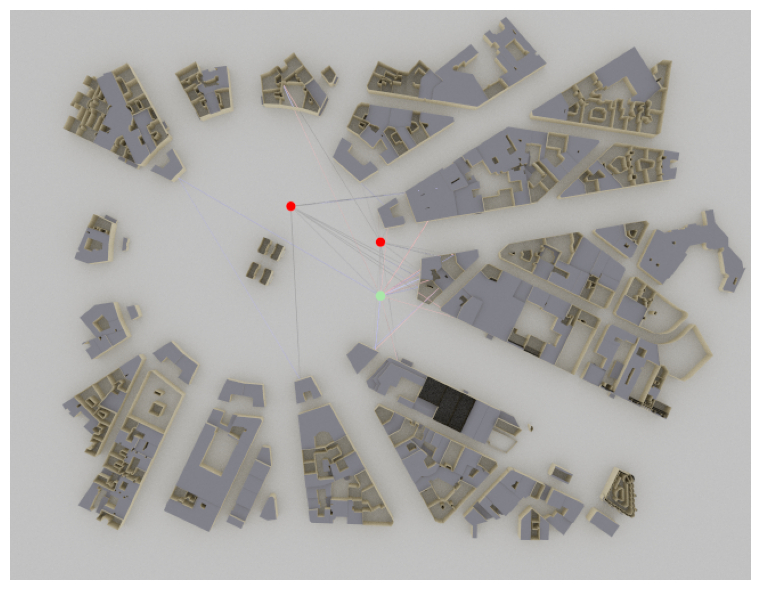

In [3]:
# ====================================================================
# Sionna RT – One-cell demo: 5 visualisations of interference effects
# 1 Constellation  2 PDP  3 |H(f)|  4 SINR hist  5 SER-vs-JNR curve
# Tested: Python 3.11 · TensorFlow 2.19 · Sionna 1.0.2 · Matplotlib 3.3
# ====================================================================

# -------------------------- 1) Scene & arrays -----------------------
# scene = load_scene()
scene = load_scene(sionna.rt.scene.etoile)
# scene = load_scene(sionna.rt.scene.munich)
iso = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.tx_array = scene.tx_array or iso
scene.rx_array = scene.rx_array or iso

tx_main = Transmitter("tx_main", position=[0, 60, 2.0]); add_safe(tx_main);
tx_i = Transmitter("tx_i", position=[-100, 100, 2.0]); add_safe(tx_i);
rx = Receiver   ("rx", position=[0, 0, 1.5]); add_safe(rx);

# # scene.munich
# tx_main = Transmitter("tx_main", position=[0, 100, 2.0]); add_safe(tx_main);
# tx_i = Transmitter("tx_i", position=[150, 170, 2.0]); add_safe(tx_i);
# rx = Receiver   ("rx", position=[200, 200, 1.5]); add_safe(rx);

tx_main.look_at(rx);  # Transmitter points towards receiver
tx_i.look_at(rx);

# ------------------ 2) Path-finding (+ auto relocate interferer) ----
solver = PathSolver()

paths = run_solver()
h_np  = paths.taps(20e6, 0, 0, normalize=False,
                   normalize_delays=True, out_type="tf").numpy().squeeze()

if h_np.shape[0] < 2:                                     # only main Tx hit
    offsets = [(-5, 0), (5, 5), (-5, 5), (0, -5), (5, -5)]
    for ox, oy in offsets:
        tx_i.position = [rx.position[0] + ox, rx.position[1] + oy, 2.0]
        tx_i.look_at(rx)
        paths = run_solver()
        h_np = paths.taps(20e6, 0, 0,
                          normalize=False, normalize_delays=True,
                          out_type="tf").numpy().squeeze()
        if h_np.shape[0] > 1:
            break                                           # interferer OK

h_main = h_np[0]
h_int  = h_np[1] if h_np.shape[0] > 1 else 0.0

# -------------------------- 3) Baseband signals ---------------------
N_SYM = 4096
bits  = np.random.randint(0, 2, (N_SYM, 2))
x     = (1 - 2*bits[:, 0] + 1j * (1 - 2*bits[:, 1])) / np.sqrt(2)

y_sig_raw = h_main * x
y_int_raw = h_int  * x

JNR_dB = 10.0
scale  = 0.0 if h_int == 0 else np.sqrt(
    np.mean(np.abs(y_sig_raw)**2) /
    np.mean(np.abs(y_int_raw)**2) / 10**(JNR_dB / 10)
)
y_int  = y_int_raw * scale

EbNo_dB = 10.0
N0      = np.mean(np.abs(y_sig_raw)**2) / (10**(EbNo_dB / 10) * 2)
noise   = np.sqrt(N0 / 2) * (np.random.randn(N_SYM) + 1j*np.random.randn(N_SYM))

y_no_i   = y_sig_raw + noise
y_with_i = y_sig_raw + y_int + noise

y_eq_no_i   = y_no_i   / h_main
y_eq_with_i = y_with_i / h_main

# --- 顯示場景預覽圖 (預設) ---
# scene.preview()

# # scene.munich
# my_cam = Camera(position=[0,0,2000], look_at=[0,2,0])
# scene.render(camera=my_cam, paths=paths, clip_at=20);

my_cam = Camera(position=[0,0,1000], look_at=[0,1,0])
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512, paths=paths, clip_at=20); # Increase num_samples to increase image quality

scene.preview(paths=paths, clip_at=20);
plt.show()

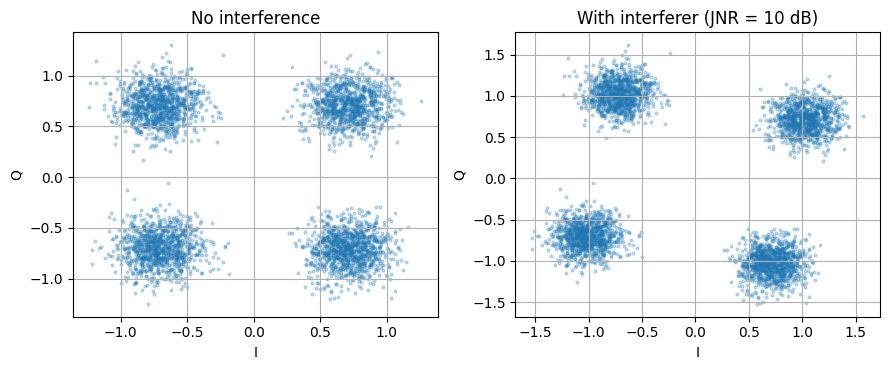

In [4]:
# -------------------------- 4) Plot 1 – constellation ---------------
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].scatter(y_eq_no_i.real,   y_eq_no_i.imag,   s=4, alpha=.25)
ax[1].scatter(y_eq_with_i.real, y_eq_with_i.imag, s=4, alpha=.25)
ax[0].set(title="No interference", xlabel="I", ylabel="Q"); ax[0].grid(True)
ttl = "With interferer (JNR = 10 dB)" if h_int != 0 else "Interferer absent"
ax[1].set(title=ttl, xlabel="I", ylabel="Q");               ax[1].grid(True)
plt.tight_layout(); plt.show()